In [34]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.autoregressive import AutoregressiveMLP, MaskedMLP, autoregressive_mask_getter
from probjax.nn.helpers import Flip, Permute

from functools import partial

import optax
from optax import adam

import jax
from jax import numpy as jnp

In [35]:
input_dim = 2

In [36]:
# Mixture of Gaussians target distribution
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)
target_samples1 = p.sample(jax.random.PRNGKey(0), (1000,)) + 5.0
target_samples2 = p.sample(jax.random.PRNGKey(1), (1000,)) - 5.0
xs = jnp.concatenate([target_samples1, target_samples2], axis=0)


In [100]:
def sliced_wasserstein2_distance(key, xs, ys, num_projections=100):
    """
    Computes the Sliced Wasserstein-2 distance between two sets of samples.

    Args:
        key: jax.random.PRNGKey
        xs: jnp.ndarray, shape (n, d)
        ys: jnp.ndarray, shape (m, d)
        num_projections: int, number of projections to use
    
    Returns:
        swd: float, sliced wasserstein distance
    """

    # Generate random projections
    projections = jax.random.normal(key, shape=(num_projections, xs.shape[1]))

    # Compute projections
    xs_projections = jnp.dot(xs, projections.T)
    ys_projections = jnp.dot(ys, projections.T)

    # Sort projections
    xs_projections = jnp.sort(xs_projections, axis=0)
    ys_projections = jnp.sort(ys_projections, axis=0)

    # Compute sliced wasserstein distance
    swd = jnp.sqrt(jnp.sum((xs_projections - ys_projections) ** 2)) / num_projections

    return swd

In [112]:

def network(x):
    return hk.nets.MLP([200, 100, 50,2])(x)

init, G = hk.without_apply_rng(hk.transform(network))
params = init(jax.random.PRNGKey(0), xs)

In [122]:
optimizer = adam(1e-2)
opt_state = optimizer.init(params)

def loss_fn(params, key, xs):
    key1, key2 = jax.random.split(key)
    eps = jax.random.normal(key1, shape=(xs.shape[0], xs.shape[1]))*5
    ys = G(params, eps)
    return jnp.mean(sliced_wasserstein2_distance(key2, xs, ys))

@jax.jit
def update(params, key, opt_state, xs):
    loss, grad = jax.value_and_grad(loss_fn)(params, key, xs)
    updates, opt_state = optimizer.update(grad, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [125]:
key = jax.random.PRNGKey(0)

for i in range(1000):
    key, subkey = jax.random.split(key)
    params, opt_state, loss = update(params, subkey, opt_state, xs)
    if i % 100 == 0:
        print(loss)

2.0029902
3.7377052


KeyboardInterrupt: 

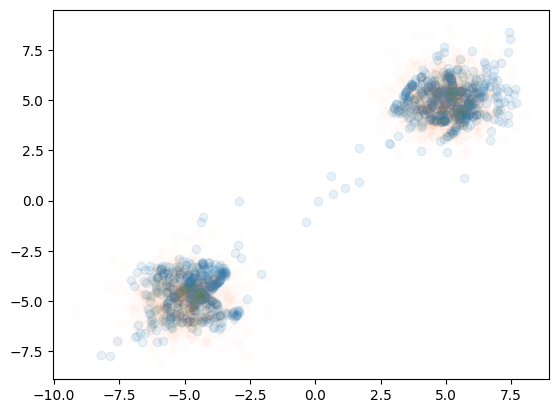

In [126]:
samples = G(params, jax.random.normal(jax.random.PRNGKey(0), shape=(1000, 2))*5)

plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)